# Part 1: Data Collection & Preprocessing
**SVG Scaling Laws Project** 

1. Mounting Google Drive & installing deps
2. Downloading SVG datasets from HuggingFace
3. Cleaning and normalizing SVGs
4. Training a BPE tokenizer
5. Creating train/val/test splits
6. Computing dataset statistics

## 1.1 Setup & Dependencies

In [7]:
# Mount Google Drive
from google.colab import drive
drive.mount("/content/drive")

import os
BASE_DIR = "/content/drive/MyDrive/svg-scaling"
for d in ["raw", "data", "tokenizer", "checkpoints", "results", "results/data_stats"]:
    os.makedirs(os.path.join(BASE_DIR, d), exist_ok=True)
print(f"Project directory: {BASE_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project directory: /content/drive/MyDrive/svg-scaling


In [3]:
# Install dependencies
!pip install -q datasets tokenizers sentencepiece lxml cairosvg mup wandb scipy seaborn Pillow tqdm pyyaml

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 7.6 MB/s eta 0:00:00


In [5]:
# Add project code to path
import sys
PROJECT_DIR = "/content/drive/MyDrive/svg-scaling-laws"
if os.path.exists(PROJECT_DIR):
    sys.path.insert(0, PROJECT_DIR)
    print(f"Project code loaded from {PROJECT_DIR}")
else:
    print(f"Upload svg-scaling-laws folder to Google Drive first!")

Project code loaded from /content/drive/MyDrive/svg-scaling-laws


## 1.2 Download Datasets

In [ ]:
from data.download_data import download_all_datasets

RAW_DIR = os.path.join(BASE_DIR, "raw")
stats = download_all_datasets(RAW_DIR)

## 1.3 Clean & Normalize SVGs

In [ ]:
from data.preprocess import preprocess_dataset

CLEANED_PATH = os.path.join(BASE_DIR, "data", "cleaned.jsonl")
preprocess_stats = preprocess_dataset(
    input_dir=RAW_DIR,
    output_path=CLEANED_PATH,
    min_length=50,
    max_length=10000,
    precision=1,
)

## 1.4 Train BPE Tokenizer

In [ ]:
from data.train_tokenizer import train_bpe_tokenizer

TOKENIZER_DIR = os.path.join(BASE_DIR, "tokenizer")
tokenizer = train_bpe_tokenizer(
    data_path=CLEANED_PATH,
    output_dir=TOKENIZER_DIR,
    vocab_size=4096,
)

## 1.5 Prepare Dataset (Tokenize -> Split -> Chunk)

In [ ]:
from data.prepare_dataset import prepare_dataset

DATA_DIR = os.path.join(BASE_DIR, "data")
dataset_stats = prepare_dataset(
    cleaned_path=CLEANED_PATH,
    tokenizer_dir=TOKENIZER_DIR,
    output_dir=DATA_DIR,
    block_size=1024,
    max_token_length=2048,
)

## 1.6 Dataset Statistics & Visualization

In [8]:
import os
BASE_DIR = "/content/drive/MyDrive/svg-scaling"
DATA_DIR = os.path.join(BASE_DIR, "data")
CLEANED_PATH = os.path.join(DATA_DIR, "cleaned.jsonl")
# You also need to run this to make sure your updated python script is loaded!
import sys
PROJECT_DIR = "/content/drive/MyDrive/svg-scaling-laws"
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)
import importlib
import data.dataset_stats
importlib.reload(data.dataset_stats)

<module 'data.dataset_stats' from '/content/drive/MyDrive/svg-scaling-laws/data/dataset_stats.py'>

In [9]:
from data.dataset_stats import compute_and_plot_stats, render_example_svgs

STATS_DIR = os.path.join(BASE_DIR, "results", "data_stats")
compute_and_plot_stats(DATA_DIR, STATS_DIR)
render_example_svgs(CLEANED_PATH, STATS_DIR, num_examples=12)

Dataset Statistics
Total files: 133,891
Filtered files: 109
Vocab size: 4096
Block size: 1024

Length stats:
  mean: 939.1314053969273
  median: 668.0
  min: 81
  max: 4096
  std: 727.7536889477054

Split stats:
  train: 131,213 files, 123,306,698 tokens
  val: 1,338 files, 1,299,907 tokens
  test: 1,340 files, 1,268,529 tokens

Saved token_length_distribution.png
Saved split_token_counts.png
Saved token_length_cdf.png
Loading SVGs for rendering examples...
  Rendered example 0: 214 chars → /content/drive/MyDrive/svg-scaling/results/data_stats/example_00_len214.png
  Rendered example 1: 739 chars → /content/drive/MyDrive/svg-scaling/results/data_stats/example_01_len739.png
  Rendered example 2: 925 chars → /content/drive/MyDrive/svg-scaling/results/data_stats/example_02_len925.png
  Rendered example 3: 1086 chars → /content/drive/MyDrive/svg-scaling/results/data_stats/example_03_len1086.png
  Rendered example 4: 1262 chars → /content/drive/MyDrive/svg-scaling/results/data_stats/example


token_length_distribution.png:


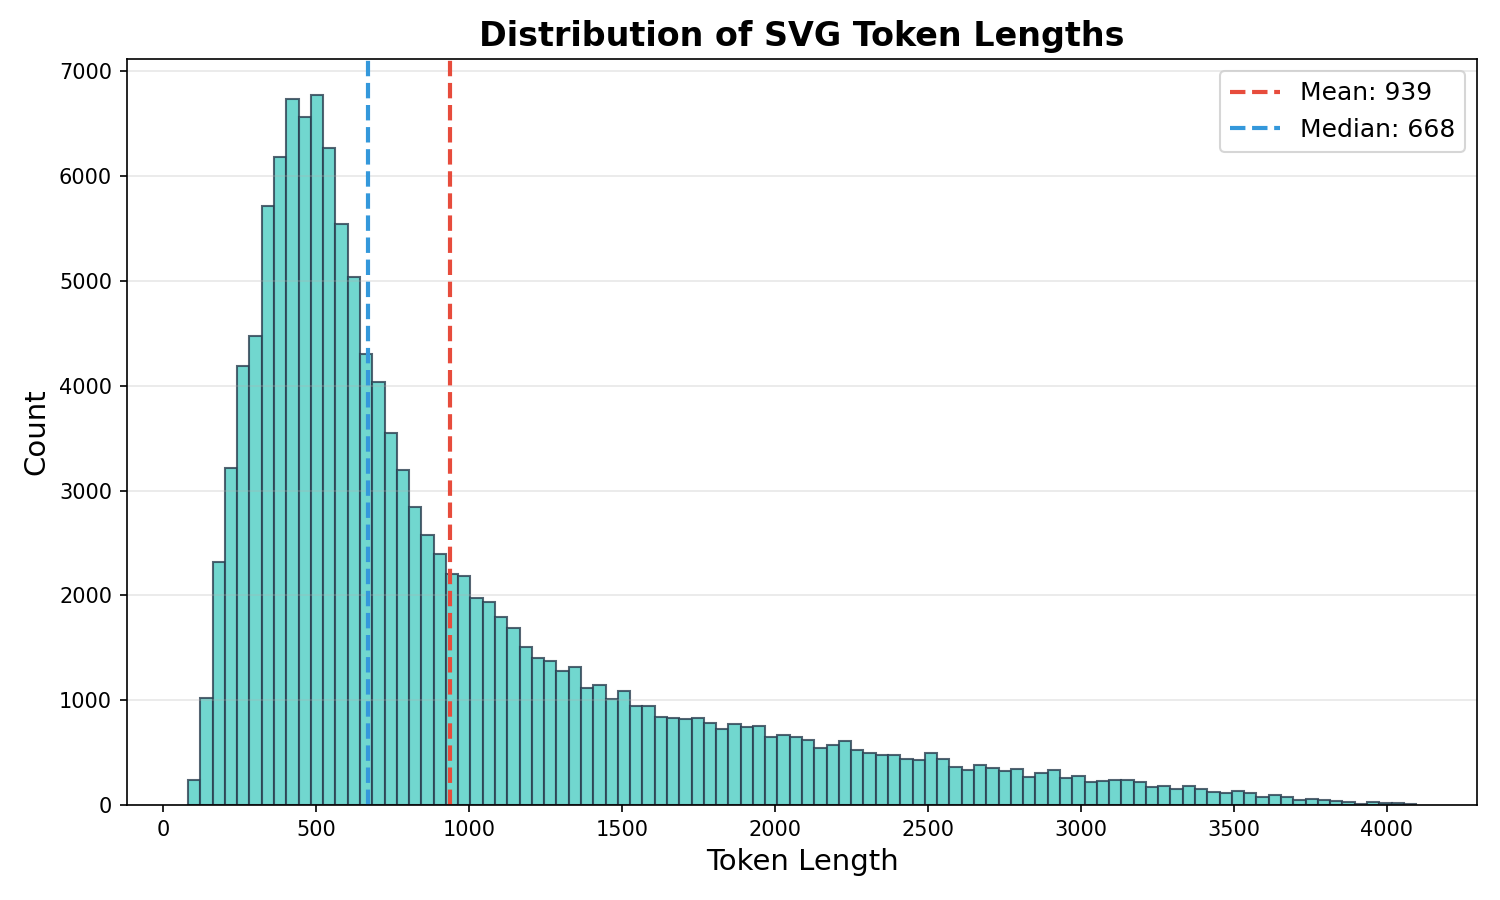


split_token_counts.png:


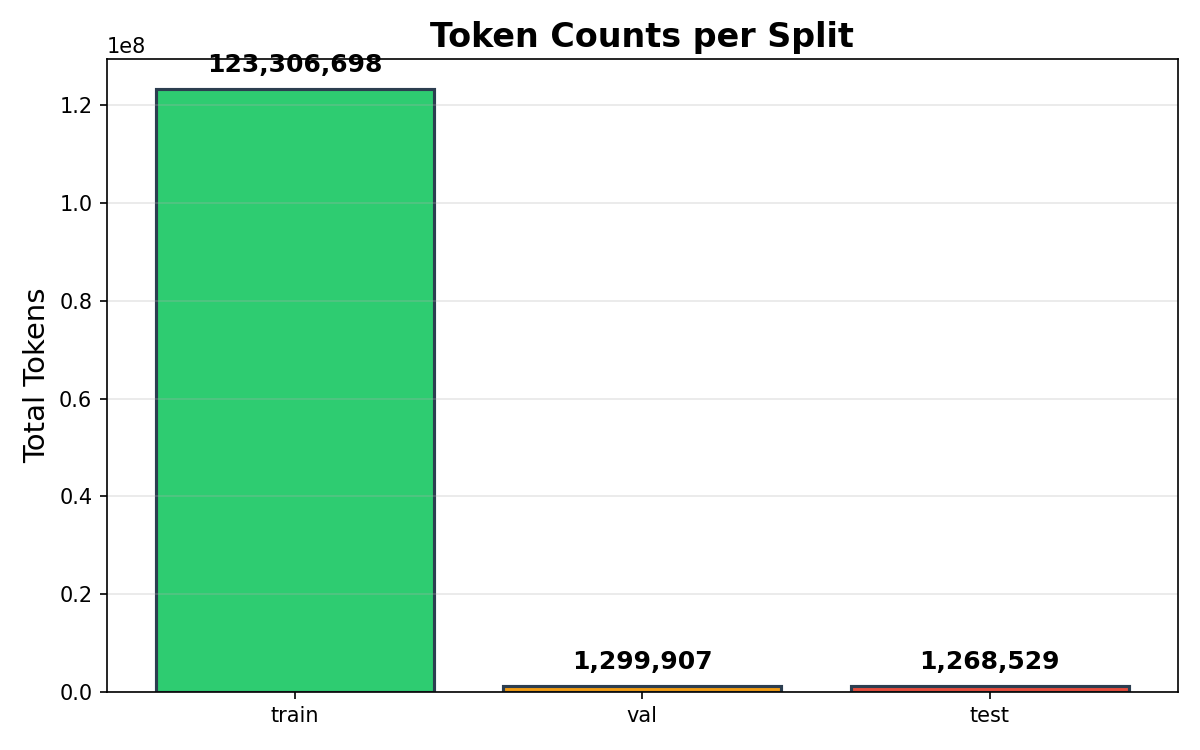


token_length_cdf.png:


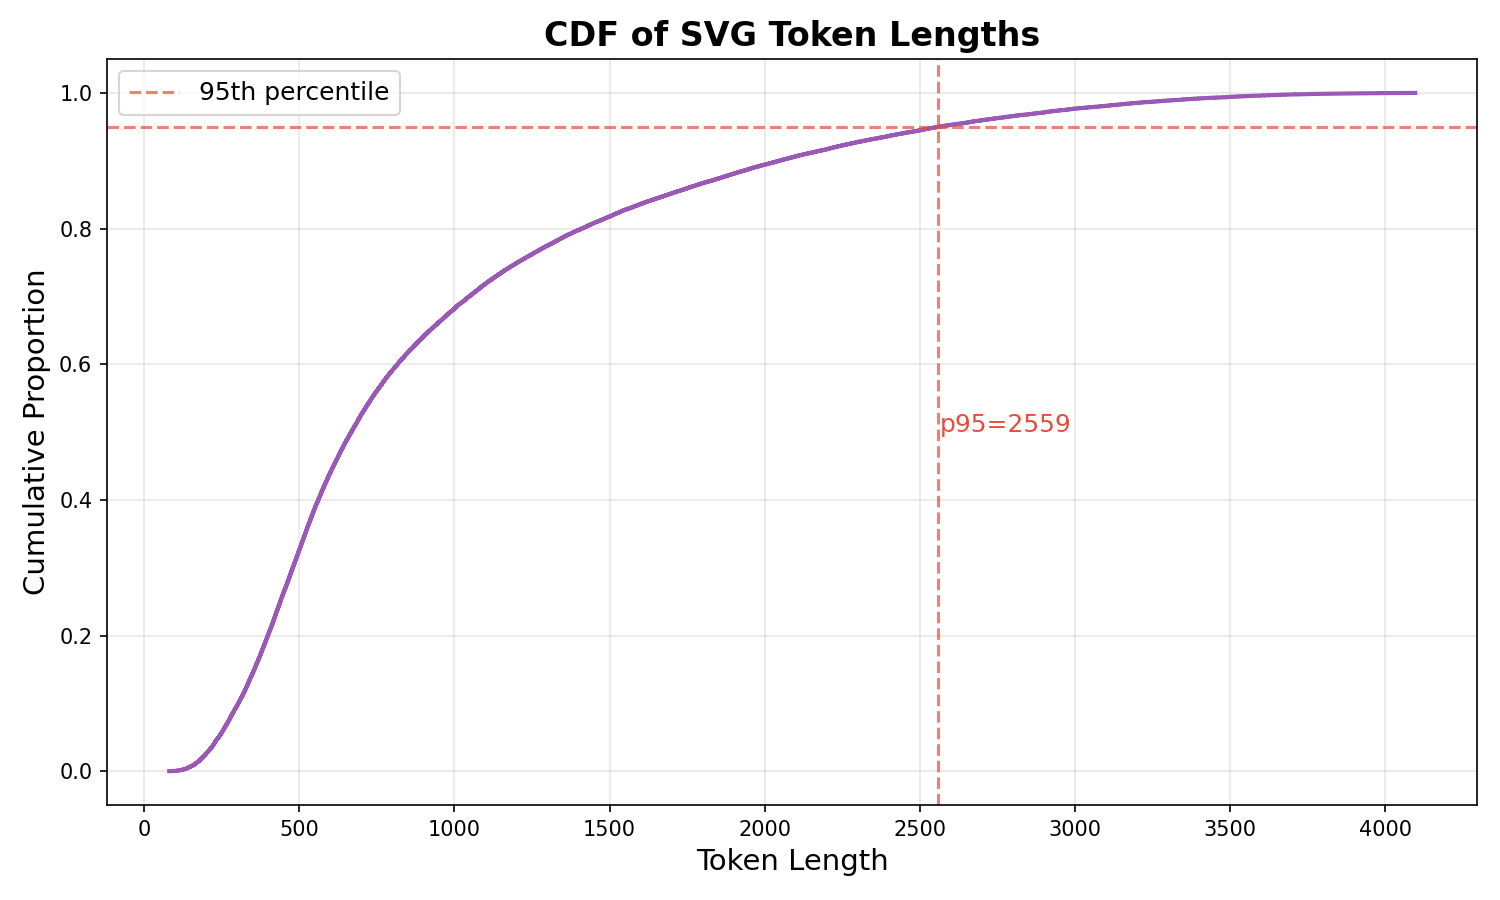


example_grid.png:


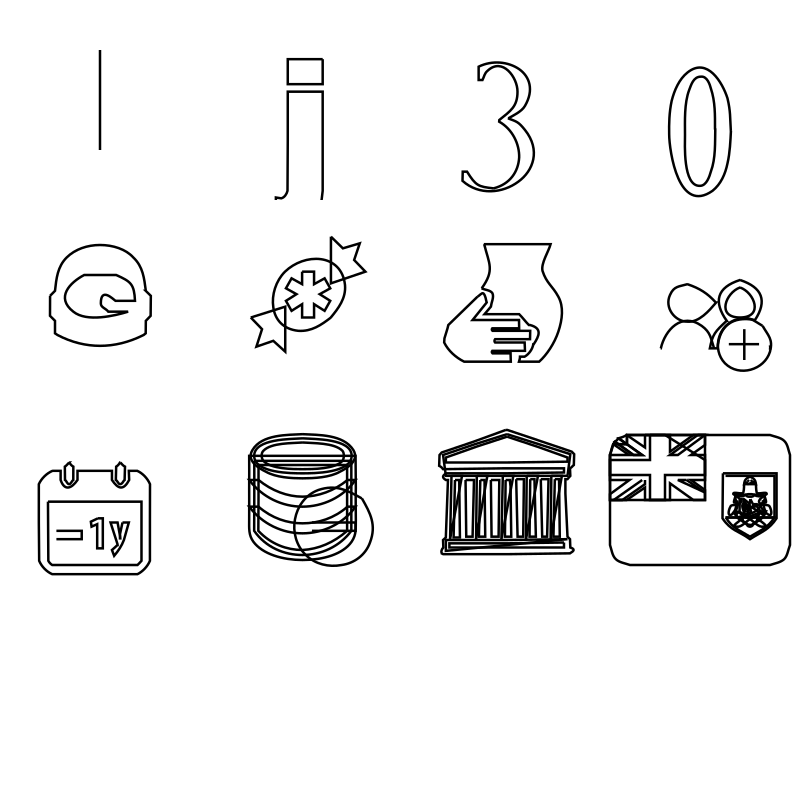

In [10]:
# Display plots inline
from IPython.display import Image, display
for img in ["token_length_distribution.png", "split_token_counts.png",
            "token_length_cdf.png", "example_grid.png"]:
    path = os.path.join(STATS_DIR, img)
    if os.path.exists(path):
        print(f"\n{img}:")
        display(Image(path, width=600))